# EWMA vs Rolling Window: Volatility and VaR Estimation

**Purpose:** Compare rolling-window and EWMA volatility estimators for the AAPL+CAT portfolio. Show how the choice of estimator affects VaR over time, and explain the lambda heuristics used in the course.

In [1]:
%matplotlib inline
import sys
sys.path.insert(0, "..")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from src.risk.lognormal import var_long_lognormal
print('Imports OK')

Imports OK


## Section 1 - Load AAPL/CAT Data

In [2]:
aapl_px = pd.read_csv('../data/AAPL-bloomberg.csv', parse_dates=['Dates'], dayfirst=False)
aapl_px = aapl_px.set_index('Dates').sort_index()['PX_LAST']

cat_px = pd.read_csv('../data/CAT-bloomberg.csv', parse_dates=['Dates'], dayfirst=False)
cat_px = cat_px.set_index('Dates').sort_index()['PX_LAST']

prices = pd.DataFrame({'AAPL': aapl_px, 'CAT': cat_px}).dropna()
prices = prices[prices.index >= pd.Timestamp('10/13/1997')]

SHARES_AAPL, SHARES_CAT = 24679, 171
port_val  = SHARES_AAPL * prices['AAPL'] + SHARES_CAT * prices['CAT']
log_ret   = np.log(port_val / port_val.shift(1)).dropna()
print(f'Portfolio log-return observations: {len(log_ret)}')
print(f'Date range: {log_ret.index[0].date()} to {log_ret.index[-1].date()}')

Portfolio log-return observations: 7126
Date range: 1997-10-14 to 2026-02-11


## Section 2 - Rolling Window Volatility

In [3]:
WINDOWS = {
    '2y': 2 * 252,
    '5y': 5 * 252,
    '10y': 10 * 252,
}

rolling_vol = {}
for label, w in WINDOWS.items():
    w_actual = min(w, len(log_ret) - 1)
    rv = log_ret.rolling(window=w_actual).std() * np.sqrt(252)
    rolling_vol[label] = rv
    print(f'Rolling {label} ({w_actual}-day) vol (latest): {rv.iloc[-1]:.4f} ({rv.iloc[-1]*100:.2f}%)')

Rolling 2y (504-day) vol (latest): 0.2757 (27.57%)
Rolling 5y (1260-day) vol (latest): 0.2731 (27.31%)
Rolling 10y (2520-day) vol (latest): 0.2861 (28.61%)


## Section 3 - EWMA Volatility

Lambda values derived from the course rule: $\lambda = 0.2^{1/N}$ (20%-weight rule) and $\lambda = 0.5^{1/h}$ (L2-optimal / half-life rule).

In [4]:
LAMBDAS = {
    '2y_ewma':  0.9972531953,   # 0.2^{1/504}
    '5y_ewma':  0.9989003714,   # 0.2^{1/1260}
    '10y_ewma': 0.9994500345,   # 0.2^{1/2520}
}

def ewma_variance(returns: pd.Series, lam: float) -> pd.Series:
    """Compute EWMA variance with decay factor lambda."""
    var = returns.pow(2).ewm(alpha=1 - lam, adjust=False).mean()
    return var

ewma_vol = {}
for label, lam in LAMBDAS.items():
    var = ewma_variance(log_ret, lam)
    vol_ann = np.sqrt(var * 252)
    ewma_vol[label] = vol_ann
    print(f'EWMA {label} (lambda={lam:.10f}) vol (latest): {vol_ann.iloc[-1]:.4f}')

EWMA 2y_ewma (lambda=0.9972531953) vol (latest): 0.2731
EWMA 5y_ewma (lambda=0.9989003714) vol (latest): 0.2855
EWMA 10y_ewma (lambda=0.9994500345) vol (latest): 0.2974


## Section 4 - Rolling vs EWMA Volatility Comparison Plot

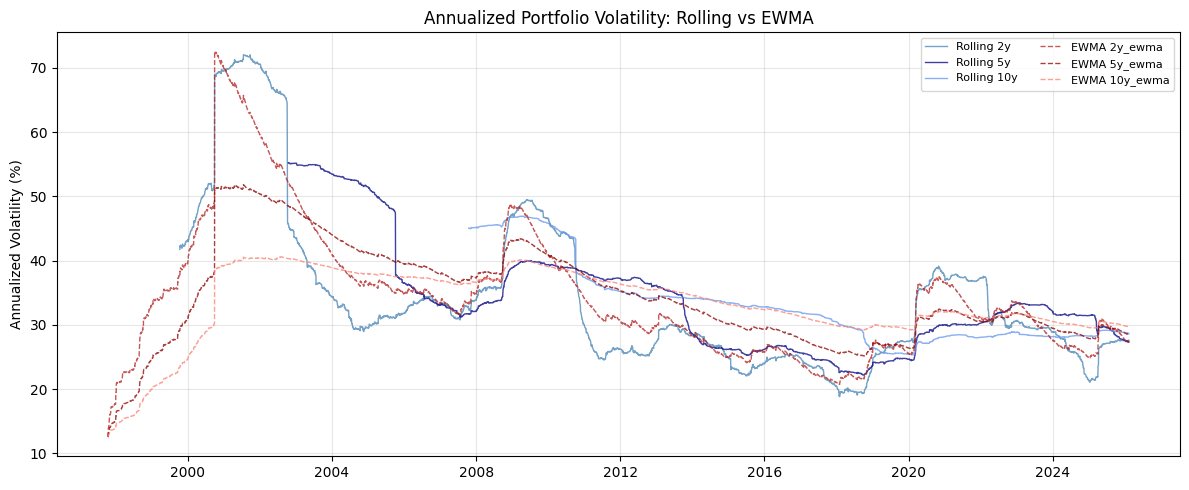

In [5]:
fig, ax = plt.subplots(figsize=(12, 5))

colors_r = ['steelblue', 'navy', 'cornflowerblue']
colors_e = ['firebrick', 'darkred', 'salmon']

for (label, rv), c in zip(rolling_vol.items(), colors_r):
    ax.plot(rv.index, rv.values * 100, label=f'Rolling {label}', color=c, alpha=0.75, lw=1)

for (label, ev), c in zip(ewma_vol.items(), colors_e):
    ax.plot(ev.index, ev.values * 100, label=f'EWMA {label}', color=c, alpha=0.75, lw=1, linestyle='--')

ax.set_ylabel('Annualized Volatility (%)')
ax.set_title('Annualized Portfolio Volatility: Rolling vs EWMA')
ax.legend(fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Section 5 - 5-Day 99% VaR Under Each Estimator

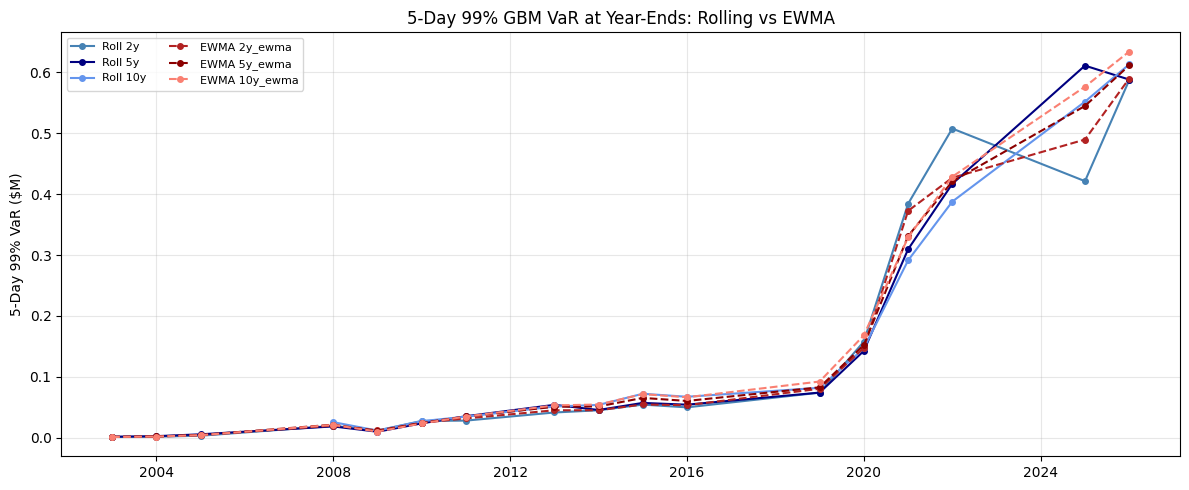

In [6]:
HORIZON = 5
VAR_CONF = 0.99

# Compute VaR at each year-end using the rolling/EWMA sigma
year_ends = pd.date_range(start='2002-12-31', end=log_ret.index[-1], freq='YE')

def sigma_to_var(sigma_ann, V0, h=5, conf=0.99, mu_ann=0.0):
    """Convert annualised sigma to 5-day GBM VaR."""
    return var_long_lognormal(V0, mu_ann + 0.5 * sigma_ann**2, sigma_ann, h / 252, conf)

var_series = {}
for label, rv in rolling_vol.items():
    vd, vv = [], []
    for d in year_ends:
        if d not in rv.index or np.isnan(rv.loc[d]):
            continue
        V0 = port_val.loc[port_val.index <= d].iloc[-1]
        sig = rv.loc[d]
        vd.append(d); vv.append(sigma_to_var(sig, V0) / 1e6)
    var_series[f'Roll {label}'] = (vd, vv)

for label, ev in ewma_vol.items():
    vd, vv = [], []
    for d in year_ends:
        if d not in ev.index or np.isnan(ev.loc[d]):
            continue
        V0 = port_val.loc[port_val.index <= d].iloc[-1]
        sig = ev.loc[d]
        vd.append(d); vv.append(sigma_to_var(sig, V0) / 1e6)
    var_series[f'EWMA {label}'] = (vd, vv)

fig, ax = plt.subplots(figsize=(12, 5))
styles = [('-', 'steelblue'), ('-', 'navy'), ('-', 'cornflowerblue'),
          ('--', 'firebrick'), ('--', 'darkred'), ('--', 'salmon')]
for (name, (xd, yv)), (ls, c) in zip(var_series.items(), styles):
    ax.plot(xd, yv, linestyle=ls, color=c, label=name, marker='o', markersize=4)
ax.set_ylabel('5-Day 99% VaR ($M)')
ax.set_title('5-Day 99% GBM VaR at Year-Ends: Rolling vs EWMA')
ax.legend(fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Section 6 - Lambda Heuristics

### Rule 1: 20%-Weight Rule
Choose $\lambda$ so that the last $N$ observations receive 20% of total weight:
$$\sum_{t=0}^{N-1} (1-\lambda)\lambda^t \approx 0.20 \implies \lambda = 0.2^{1/N}$$

| Window | N (days) | $\lambda = 0.2^{1/N}$ |
|--------|----------|---------------------|
| 2 years | 504 | 0.99725 |
| 5 years | 1260 | 0.99890 |
| 10 years | 2520 | 0.99945 |

### Rule 2: Half-Life Rule (L2-optimal)
Choose $\lambda$ so that the weight halves every $h$ days (i.e., the EWMA 'half-life' is $h$):
$$\lambda^h = 0.5 \implies \lambda = 0.5^{1/h}$$

**Key observation:** EWMA reacts faster to volatility spikes (2008, 2020 COVID crash) because it downweights old observations exponentially. Rolling windows show a 'cliff edge' when crisis observations drop out of the window.